# Data Cleaning & Data Analytics

## CPlus-Umfrage

Im Rahmen eines CPlus-Projektes wurden zwölf Cluster in sechs mitteleuropäischen Ländern untersucht. 

Dazu wurde ein Fragebogen erstellt, bei dem jede latente Variable anhand mehrerer Items operationalisiert wurde. Für jedes Item wurde eine Aussage formuliert, die mithilfe einer 7-Punkte-Likert-Skala („Stimme überhaupt nicht zu“, …, „Stimme voll und ganz zu“) beantwortet werden konnte.

Übersicht über die Items

* CD3-CD5 ... Daten zum Unternehmen (Gründungsjahr, Anzahl der Angestellten, Land)
* CL_NR ... Cluster-Nummer innerhalb eines Landes
* TR1-TR4 ... Statements zur Trust in Region (1 fully disagree, 7 fully agree)
* DI1-DI4 ...  Statements zu Environmental Dynamism (1 fully disagree, 7 fully agree)
* EC1-EC3 ... Statements zu Environmental Competitiveness (1 fully disagree, 7 fully agree)
* IP1-IP5 ... Statements zu Exploitative Innovation (1 fully disagree, 7 fully agree)
* IP6-IP14 ... Statements zu Explorative Innovation (1 fully disagree, 7 fully agree)
* PI1-PI3 ... Statements zu Process Innovation  (1 fully disagree, 7 fully agree)
* CI1-CI9 ... Statements zu Acquire and Assimilate Knowledge (1 fully disagree, 7 fully agree)
* TI1-TI12 ... Statements zu Transform and Exploit Knowledge (1 fully disagree, 7 fully agree)
* BS1-BS6 ... Statements zu Business Strategy (1 fully disagree, 7 fully agree)
* CM0-CM4  ... Statements zu Kooperation with Cluster Management (1 fully disagree, 7 fully agree)
* FP1-FP3  ... Statements zu Financial Performance (1 fully disagree, 7 fully agree)


In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set(style="whitegrid", context="notebook")

# Teil: Daten einlesen, erste Übersicht und Korrektur


In [61]:
# Einlesen der Daten
df = pd.read_csv("daten/CPlus-Rohdaten.csv")
df.shape

(257, 66)

In [62]:
# Ausgabe der ersten Zeilen, Dimensionen und Spaltennamen
df.head()

,CD3,CD4,CD5,CL_NR,TR1,TR2,TR3,TR4,DI1,DI2,DI3,DI4,EC1,EC2,EC3,IP1,IP2,IP3,IP4,IP5,IP6,IP7,IP8,IP9,IP10,IP11,IP13,IP14,PI1,PI2,PI3,CI1,CI2,CI3,CI4,CI5,CI6,CI7,CI8,CI9,TI1,TI2,TI3,TI4,TI5,TI6,TI7,TI8,TI9,TI10,TI11,TI12,BS1,BS2,BS3,BS4,BS5,BS6,CM0,CM1,CM2,CM3,CM4,FP1,FP2,FP3
0,2002,20,1,2,6,7,4,7,7,7,1,7,7,6,4,7,7,3,2,3,3,7,1,4,4,1,5,70,7,7,1,3,5,4,5,1,2,5,7,7,4,6,5,1,5,2,7,1,7,4,1,6,1,5,1,1,1,1,1,2,7,5,1,6,5,5
1,2007,6,1,2,6,7,3,7,4,7,1,3,4,7,2,7,7,4,7,7,1,7,3,7,7,6,5,50,4,4,1,7,7,1,7,1,1,1,7,7,7,7,7,1,1,7,7,1,7,7,7,7,7,6,7,7,7,1,1,1,7,6,2,4,4,6
2,2001,12,1,2,5,6,5,4,4,7,1,5,3,6,2,6,6,5,4,2,3,5,6,3,3,4,3,20,7,6,2,7,6,6,1,1,4,4,7,5,5,6,5,2,4,3,5,2,5,4,3,6,3,6,5,6,6,5,1,3,5,4,2,3,2,2
3,2008,10,1,2,5,6,4,6,7,7,1,5,4,6,3,7,7,7,5,2,2,4,5,4,6,7,5,70,6,7,4,3,5,5,3,1,6,2,7,7,7,4,7,1,2,4,4,1,5,4,2,4,4,4,6,6,6,5,1,7,1,7,7,5,4,7
4,1985,350,1,2,2,3,3,6,6,5,1,5,5,6,5,5,5,4,4,6,1,5,6,4,6,2,3,15,6,6,1,5,4,6,2,1,5,2,5,5,5,6,4,1,3,5,6,1,6,4,2,6,2,5,7,7,6,2,1,6,6,5,2,4,4,6


In [63]:
# einige statistische Kennzahlen
df.describe().round(2)

,CD3,CD4,CD5,CL_NR,TR1,TR2,TR3,TR4,DI1,DI2,DI3,DI4,EC1,EC2,EC3,IP1,IP2,IP3,IP4,IP5,IP6,IP7,IP8,IP9,IP10,IP11,IP13,IP14,PI1,PI2,PI3,CI1,CI2,CI3,CI4,CI5,CI6,CI7,CI8,CI9,TI1,TI2,TI3,TI4,TI5,TI6,TI7,TI8,TI9,TI10,TI11,TI12,BS1,BS2,BS3,BS4,BS5,BS6,CM0,CM1,CM2,CM3,CM4,FP1,FP2,FP3
count,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.0,257.00,257.00,257.00,257.00,257.00,257.00,257.0,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00,257.00
mean,1991.61,101.51,3.61,1.52,4.40,4.72,3.73,4.85,5.06,5.19,2.69,4.37,4.89,5.07,4.90,5.3,5.40,4.92,5.13,5.37,4.03,4.91,4.5,4.36,4.51,3.80,3.49,11.00,4.26,4.41,3.79,4.31,4.87,4.23,3.17,2.58,4.05,2.96,5.27,5.05,5.00,4.61,4.88,2.77,3.43,4.31,5.57,1.95,5.77,5.33,3.34,5.30,4.72,4.74,4.92,5.09,4.94,3.54,1.23,5.01,4.17,5.30,4.53,4.93,5.00,5.13
std,18.39,321.70,1.77,0.50,1.73,1.50,1.80,1.62,1.71,1.75,2.00,1.65,1.88,1.76,1.92,1.7,1.69,1.80,1.84,1.70,2.12,1.88,2.0,2.00,1.80,1.95,1.54,40.04,2.01,1.94,2.16,1.95,1.64,2.04,1.97,1.97,2.01,1.66,1.51,1.54,1.57,1.80,1.60,1.80,1.96,2.02,1.58,1.68,1.66,1.56,1.89,1.57,2.08,1.92,2.07,2.01,1.77,1.97,0.53,2.31,2.45,1.99,2.39,1.76,1.74,1.73
min,1910.00,-66.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,-77.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,1990.00,6.00,2.00,1.00,3.00,4.00,2.00,4.00,4.00,4.00,1.00,3.00,4.00,4.00,4.00,4.0,5.00,4.00,4.00,5.00,2.00,4.00,3.0,3.00,3.00,2.00,2.00,0.00,3.00,3.00,2.00,3.00,4.00,2.00,2.00,1.00,2.00,2.00,4.00,4.00,4.00,3.00,4.00,1.00,2.00,2.00,5.00,1.00,5.00,5.00,2.00,4.00,3.00,3.00,3.00,4.00,4.00,2.00,1.00,3.00,2.00,4.00,2.00,4.00,4.00,4.00
50%,1996.00,19.00,4.00,2.00,5.00,5.00,4.00,5.00,5.00,6.00,2.00,4.00,5.00,6.00,5.00,6.0,6.00,5.00,6.00,6.00,4.00,5.00,5.0,4.00,5.00,4.00,3.00,8.00,4.00,4.00,4.00,4.00,5.00,4.00,2.00,2.00,4.00,2.00,6.00,5.00,5.00,5.00,5.00,2.00,3.00,5.00,6.00,1.00,6.00,6.00,3.00,6.00,5.00,5.00,6.00,6.00,5.00,3.00,1.00,6.00,4.00,6.00,5.00,5.00,5.00,5.00
75%,2003.00,70.00,5.00,2.00,6.00,6.00,5.00,6.00,6.00,7.00,4.00,6.00,6.00,6.00,7.00,7.0,7.00,6.00,7.00,7.00,6.00,7.00,6.0,6.00,6.00,5.00,5.00,30.00,6.00,6.00,6.00,6.00,6.00,6.00,5.00,4.00,6.00,4.00,6.00,6.00,6.00,6.00,6.00,4.00,5.00,6.00,7.00,2.00,7.00,6.00,5.00,6.00,7.00,6.00,7.00,7.00,6.00,5.00,1.00,7.00,6.00,7.00,7.00,6.00,6.00,6.00
max,2011.00,3600.00,6.00,2.00,8.00,8.00,8.00,8.00,7.00,7.00,7.00,7.00,8.00,7.00,8.00,8.0,8.00,8.00,8.00,8.00,8.00,8.00,8.0,8.00,8.00,8.00,6.00,100.00,8.00,8.00,8.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,3.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00


In [64]:
# Anzahl an fehlenden Werten: keine?
df.isna().sum().sum()

np.int64(0)

## Fehlende Werte codieren

In [65]:
# Für spezielle Spalten
df["CD4"] = df["CD4"].replace(-66, np.nan)
df["IP14"] = df["IP14"].replace(-77, np.nan)

In [66]:
# Für Likert-Skalen (1..7)
likert_cols = [
    "TR1", "TR2", "TR3", "TR4", "DI1", "DI2", "DI3", "DI4", "EC1", "EC2", "EC3",
    "IP1", "IP2", "IP3", "IP4", "IP5", "IP6", "IP7", "IP8", "IP9", "IP10", "IP11",
    "PI1", "PI2", "PI3", "CI1", "CI2", "CI3", "CI4", "CI5", "CI6", "CI7", "CI8", "CI9",
    "TI1", "TI2", "TI3", "TI4", "TI5", "TI6", "TI7", "TI8", "TI9", "TI10", "TI11", "TI12",
    "BS1", "BS2", "BS3", "BS4", "BS5", "BS6", "CM1", "CM2", "CM3", "CM4",
    "FP1", "FP2", "FP3",
]

# 8 kann nicht vorkommen -> Codierung für NA
df[likert_cols] = df[likert_cols].replace(8, np.nan)

In [67]:
# hier gibt es keine zusätzlichen Werte (= alle haben Frage beantwortet)
df["CM0"].value_counts()

CM0
1    212
2     32
3     13
Name: count, dtype: int64

In [68]:
# Skala war nur von 1..5
df["IP13"].value_counts()

IP13
5    79
3    58
1    39
4    35
2    32
6    14
Name: count, dtype: int64

In [69]:
# Deshalb ist 6 eine "Nicht-Antwort" -> NA
df["IP13"] = df["IP13"].replace(6, np.nan)

In [70]:
df.isna().sum()

CD3       0
CD4       3
CD5       0
CL_NR     0
TR1       2
         ..
CM3      34
CM4      33
FP1      40
FP2      41
FP3      38
Length: 66, dtype: int64

## Werte anpassen

In [71]:
# Likert-Skala anpassen
# Negative Fragen einfach umkodieren: aus 7 wird 1 und umgekehrt.
reverse_cols = ["DI3", "CI4", "CI5", "CI7", "TI4", "TI5", "TI8", "TI11", "BS6", "CM2"]
df[reverse_cols] = df[reverse_cols].apply(lambda v: 8 - v)

In [72]:
# Weitere Daten ableiten
# CD5=Land, CL_NR=1 oder 2 (es gab 2 Cluster pro Land)
df["ClusterNr"] = (df["CD5"] * 10 + df["CL_NR"]).astype("Int64").astype("category")
df["FirmAge"] = 2012 - df["CD3"]  # Umfrage fand 2012 statt
df[["ClusterNr", "FirmAge"]].head()

,ClusterNr,FirmAge
0,12,10
1,12,5
2,12,11
3,12,4
4,12,27


In [73]:
# Und weil die Daten so schieflastig sind -> Log-Transformation
df["FirmAgeLog"] = np.log2(df["FirmAge"])
df["FirmSizeLog"] = np.log2(df["CD4"])

In [74]:
# Nützliche Definitionen für später
items_all = list(df.columns)

# nur Variablen, d.h. keine Clusternummer, untransformierte Firmengröße, etc. IP14 siehe unten
items_vars = [c for c in items_all if c not in ["CD3", "CD4", "CD5", "CL_NR", "ClusterNr", "IP14", "FirmAge", "CM0"]]

# latent -> keine harten Fakten
items_latent = [c for c in items_vars if c not in ["FirmAgeLog", "FirmSizeLog"]]

# Abhängige Variable für Regressionsmodelle
items_abh = [
    "IP1", "IP2", "IP3", "IP4", "IP5",          # exploitive innovation
    "IP6", "IP7", "IP8", "IP9", "IP10", "IP11", # explorative innovation
    "PI1", "PI2", "PI3",  # process innovation
    "FP1", "FP2", "FP3",  # financial performance
    "IP13",               # Kennzahl für Innovations-Erfolg
]

# alle anderen sind unabhängige Variable
items_unabh = [c for c in items_latent if c not in items_abh]

## Weitere Ungereimtheiten

In [75]:
# CMx: da stimmt auch was nicht...
# CM0==3 heißt: in unserer Region gibt es keinen Cluster -> es kann daher auch keine Beziehung dazu geben...
df.query("CM0 == 3 and CM1.notna()")[["CM0", "CM1", "CM2", "CM3", "CM4"]]

,CM0,CM1,CM2,CM3,CM4
67,3,7.0,7.0,7.0,7.0
104,3,6.0,NaN,NaN,NaN
218,3,7.0,7.0,7.0,7.0


In [76]:
# daher: Daten verwerfen (betrifft nur 3 Zeilen)
df.loc[df["CM0"] == 3, ["CM1", "CM2", "CM3", "CM4"]] = np.nan

np.int64(73)

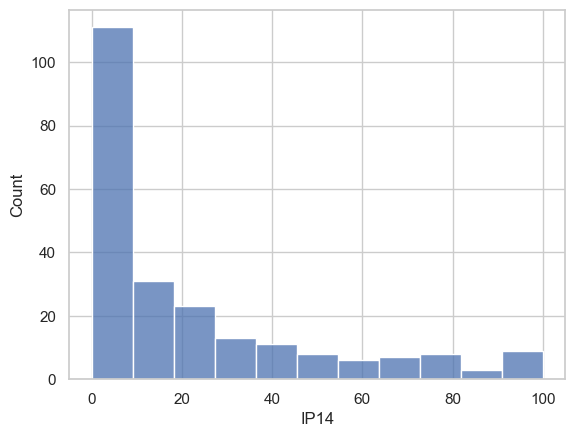

In [77]:
# IP14: relativen Umsatzanteil des Jahres 2010 (in %), der durch neu eingeführte Produkte und/oder Dienstleistungen erzielt wurde.
sns.histplot(df["IP14"])

(df["IP14"]==0).sum() # 73 Firmen

Bei `IP14` sind 73 Einträge 0. Das kann zweierlei bedeuten:
1. fehlende Einträge wurden bei der Eingabe falsch als 0 codiert oder
2. es gibt viele Firmen, die im abgefragten Zeitraum keine neuen Produkte auf den Markt gebracht haben.

Zudem sind ca. 20 Firmen so jung, dass sie genau in diesen Zeitraum fallen. Wir könnten nun eine längere Analyse versuchen, um anhand der Daten herauszufinden, welches der wahrscheinlichere Fall ist (echt keine Erfindungen oder falsch codiert). Mehr als 30 Firmen haben parallel zu `IP14 = 0` einen Wert `IP13 > 1` angekreuzt, was für interne Inkonsistenzen spricht. Kurz, diese Maßzahl ist nicht vertrauenswürdig.

Wir müssen `IP14` **ersatzlos** streichen. Das tut weh, denn nun bleibt als Kennzahl für die Innovationsleistung eines Unternehmens nur noch die Antwort `IP13` übrig.

# Konstrukte bauen / testen

In [78]:
import fragebogen

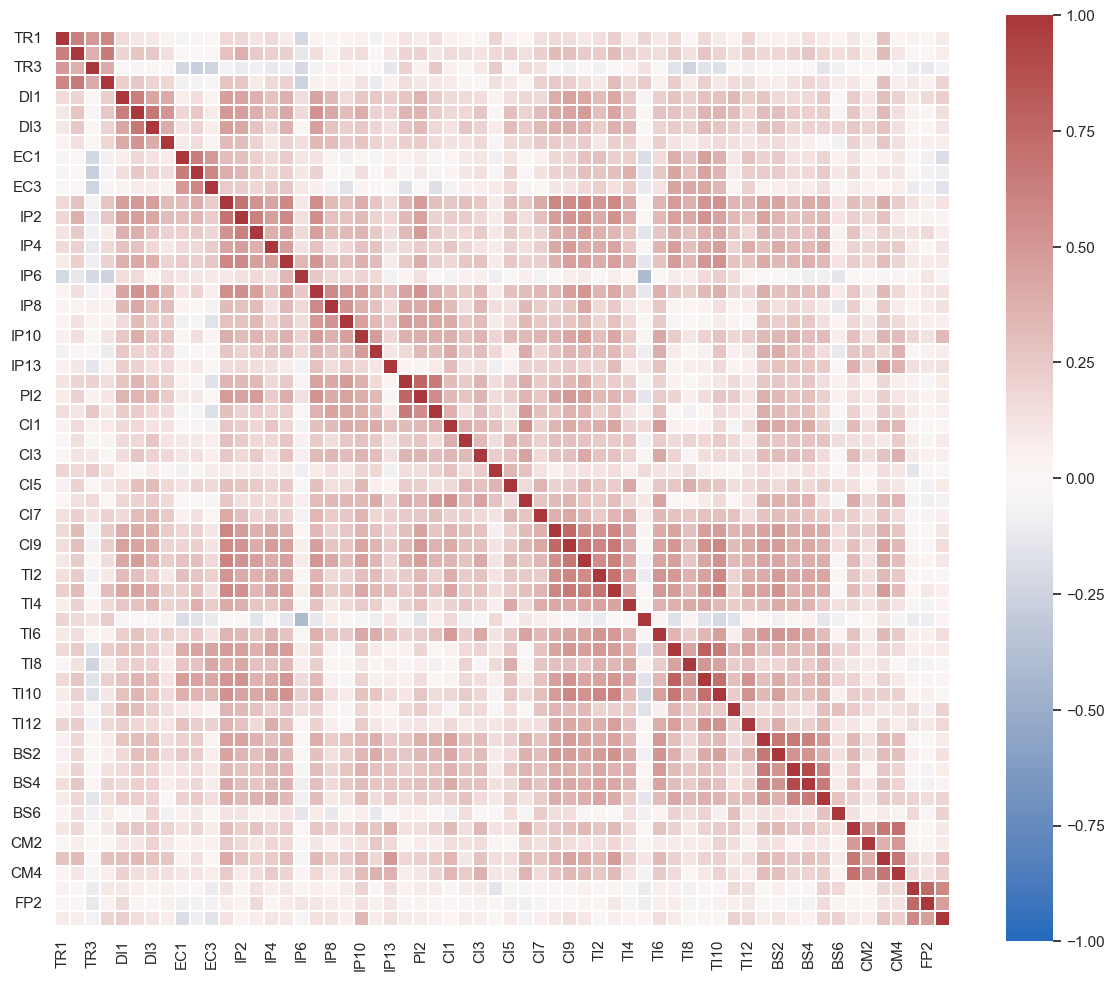

In [79]:
# Fangen wir mit einer Korrelation der Items an
# Wir sollten einiges an Korrelation sehen, denn es gibt immer mehrere Items zu einem Konstrukt
fragebogen.plot_corr(df[items_latent], figsize=(12, 10))

In [80]:
# Für die erste Kontrolle akzeptieren wir mal, dass es nur die Hälfte der Daten sind
df[items_latent].dropna().shape

(152, 60)

## Faktoren-Analyse

Im nächsten Schritt setzen wir nun unsere eigentlichen Messgrößen/Konstrukte aus den einzelnen Fragen zusammen.
Die wichtigste Frage dabei: sind die Antworten auf die Fragen für einen einzelnen Faktor so kohärent, dass wir
gefahrlos die Antworten zu einem einzigen Wert kombinieren können?

In [81]:
import factor_analyzer as fa

### Bartlett-Test

Der Bartlett-Test auf Sphärizität prüft, ob die Korrelationsmatrix der untersuchten Variablen signifikant von einer Einheitsmatrix abweicht. Die Nullhypothese lautet, dass zwischen den Variablen keine Zusammenhänge bestehen (alle Korrelationskoeffizienten außerhalb der Diagonale sind gleich null). Ein statistisch signifikanter Test (p < 0,05) spricht dafür, dass ausreichende Korrelationen zwischen den Variablen vorliegen und eine Faktorenanalyse grundsätzlich sinnvoll ist. Ein nicht signifikanter Test deutet hingegen darauf hin, dass die Variablen nur schwach oder gar nicht zusammenhängen und sich daher möglicherweise nicht für eine Faktorenanalyse eignen.

Beim Bartlett-Test sollte der p-Wert kleiner als 0,05 sein. Der Chi-Quadrat-Wert ist nicht interessant für uns.

In [82]:
# Bartlett-Test: ist ausreichend Korrelationen vorhanden?
# Ergebnis: (chi-square, p-Wert)
fa.calculate_bartlett_sphericity(df[items_latent].dropna())

(np.float64(6247.77658433776), np.float64(0.0))

### KMO-Kriterium

Mithilfe eines weiteren Tests, dem **Kaiser-Meyer-Olkin-Kriterium**, können wir überprüfen, ob unsere Antworten
ausreichend stabil sind. Ein Gesamtwert größer 0.5 ist ein gutes Indiz. Wir prüfen auch, ob die einzelnen
Variable gut passen:

In [83]:
fragebogen.kmo_kriterium(df[items_latent]).head(10)

kmo_overall=0.83


,value
CI4,0.466758
FP2,0.478975
FP1,0.491077
BS6,0.580195
CM2,0.599198
FP3,0.617491
TR3,0.633332
IP6,0.637688
TI5,0.655347
TR1,0.707140


Für einzelne Variable gilt: <.5 ist schlecht, <.7 mittelmäßig, <.8 ok, <.9 gut, >.9 sehr gut

* Die Spalten FP1 und FP2 interessieren uns in Folge nicht, d.h. dort stören uns die niederen Werte nicht.
* CI4 gibt etwas Anlass zur Sorge: das war eine invers-kodierte Frage und könnte auf Nachlässigkeit beim Ausfüllen des Fragebogens hindeuten. 
* Andererseits: es ist die einzige Frage nach "Lieferanten" in diesem Block.

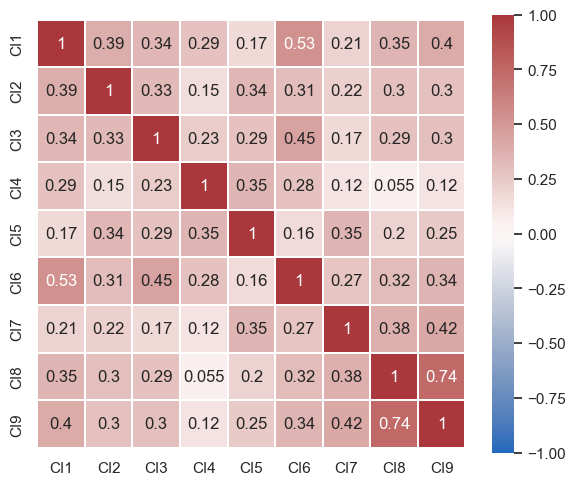

In [84]:
# Schauen wir uns die Korrelation mit anderen Fragen in diesem Block näher an:
fragebogen.plot_corr(df[["CI1", "CI2", "CI3", "CI4", "CI5", "CI6", "CI7", "CI8", "CI9"]], annot=True)

## Konstrukte

Wir rechnen damit, dass unsere Fragen für fünf abhängige latente Faktoren stehen:

* Exploitative Innovation (inkrementell, ausschöpfend): IP1, IP2, IP3, IP4, IP5
* Explorative Innovation (neu, disruptiv, kreativ): IP6, IP7, IP8, IP9, IP10, IP11
* Prozessinnovation: PI1, PI2, PI3
* Finanzielle Performance: FP1, FP2, FP3
* Innovationserfolg: IP13

In [85]:
# Kaiser-Kriterium: wie viele sind >1?
fragebogen.kaiser_kriterium(df[items_abh])
# 5 :-) Sehr schön

np.int64(5)

## Parallelanalyse

Die Parallelanalyse vergleicht die Eigenwerte der echten Daten mit Eigenwerten aus zufällig erzeugten Daten gleicher Größe.

Die Logik ist: Behalte nur jene Komponenten oder Faktoren, deren Eigenwert in den echten Daten größer ist als der entsprechende Eigenwert in Zufallsdaten.

Die Funktion liefert zwei verschiedene Werte:

Komponenten beziehen sich auf eine PCA. Dabei wird die gesamte Varianz der Variablen analysiert. Die Frage lautet: Wie viele Hauptkomponenten erklären mehr Varianz als Zufallsdaten?

Faktoren beziehen sich auf eine Faktorenanalyse. Dabei geht es nur um die gemeinsame Varianz der Variablen. Die Frage lautet: Wie viele latente Faktoren sind sinnvoll, weil sie mehr gemeinsame Struktur zeigen als Zufallsdaten?

Ein kleiner Unterschied zwischen Daten und Random ist kritisch zu betrachten. Wenn der echte Eigenwert nur minimal über dem zufälligen Eigenwert liegt, ist das ein schwaches Signal. Dann sollte man die Entscheidung nicht mechanisch treffen, sondern zusätzlich prüfen:

Plot: Gibt es einen klaren Knick?
Interpretierbarkeit: Ist der Faktor sinnvoll benennbar?
Ladungen: Laden mehrere Items deutlich auf diesen Faktor?
Stabilität: Kommt dieselbe Lösung bei anderen Stichproben/Teilmengen wieder heraus?
Theoretische Erwartung: Passt die Anzahl der Faktoren inhaltlich?

**Faustregel:** Die Parallelanalyse ist eine Entscheidungshilfe, keine automatische Wahrheit. Besonders wenn der Eigenwert der echten Daten nur knapp über dem Zufallswert liegt, sollte man die zusätzliche Komponente bzw. den zusätzlichen Faktor vorsichtig interpretieren und nur behalten, wenn sie/er auch inhaltlich sinnvoll und statistisch stabil ist.

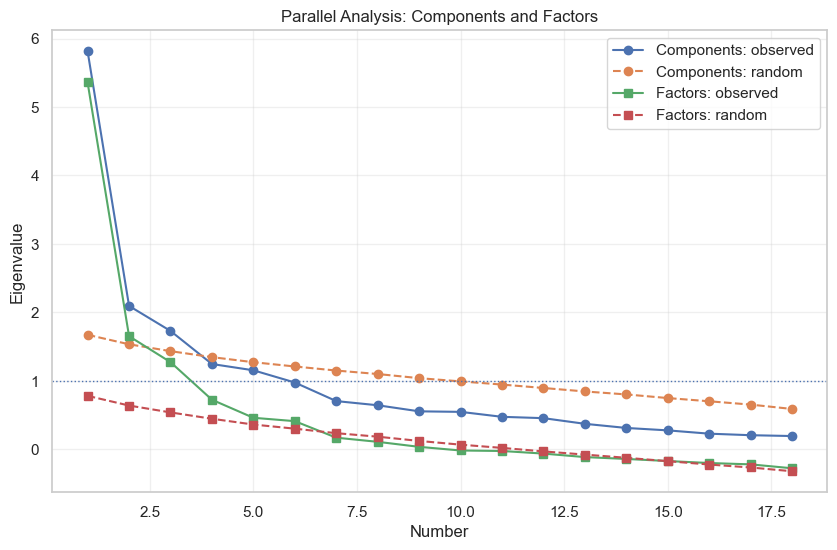

Empfohlene Anzahl an Komponenten: 3
Empfohlene Anzahl an Faktoren: 6


In [86]:
pa_abh = fragebogen.parallel_analysis(df[items_abh], n_iter=500, fa="both")
fragebogen.plot_parallel_analysis(pa_abh)

In [87]:
fragebogen.print_factor_loadings(df[items_abh], n_factors=5)

                   F1     F2     F3     F4     F5
IP1             0.777                            
IP2             0.969                            
IP3             0.617                            
IP4             0.530                            
IP5             0.621                            
IP6                                         0.919
IP7                                  0.468       
IP8                                  0.526       
IP9                                  0.577       
IP10                                 0.607       
IP11                                 0.542       
PI1                    0.989                     
PI2                    0.752                     
PI3                    0.620                     
FP1                           1.013              
FP2                           0.771              
FP3                           0.550              
IP13                                             

SS loadings     2.768  2.171  1.960  1.817  1.012

In [88]:
items_abh2 = [x for x in items_abh if x not in ["IP13"]]
fragebogen.print_factor_loadings(df[items_abh2], n_factors=4)

                   F1     F2     F3     F4
IP1             0.750                     
IP2             0.966                     
IP3             0.613                     
IP4             0.505                     
IP5             0.598                     
IP6                                       
IP7                                  0.423
IP8                                  0.471
IP9                                  0.472
IP10                                 0.565
IP11                                 0.591
PI1                    1.019              
PI2                    0.715              
PI3                    0.686              
FP1                           1.001       
FP2                           0.748       
FP3                           0.570       

SS loadings     2.672  2.407  1.911  1.675
Proportion Var  0.157  0.142  0.112  0.099
Cumulative Var  0.157  0.299  0.411  0.510


In [89]:
items_abh3 = [x for x in items_abh if x not in ["IP13", "IP6"]]
fragebogen.print_factor_loadings(df[items_abh3], n_factors=4)

                   F1     F2     F3     F4
IP1             0.764                     
IP2             0.981                     
IP3             0.632                     
IP4             0.530                     
IP5             0.653                     
IP7                                  0.401
IP8                                  0.489
IP9                                  0.512
IP10                                 0.675
IP11                                 0.667
PI1                    1.052              
PI2                    0.721              
PI3                    0.596              
FP1                           1.008       
FP2                           0.748       
FP3                           0.563       

SS loadings     2.847  2.200  1.916  1.803
Proportion Var  0.178  0.138  0.120  0.113
Cumulative Var  0.178  0.315  0.435  0.548


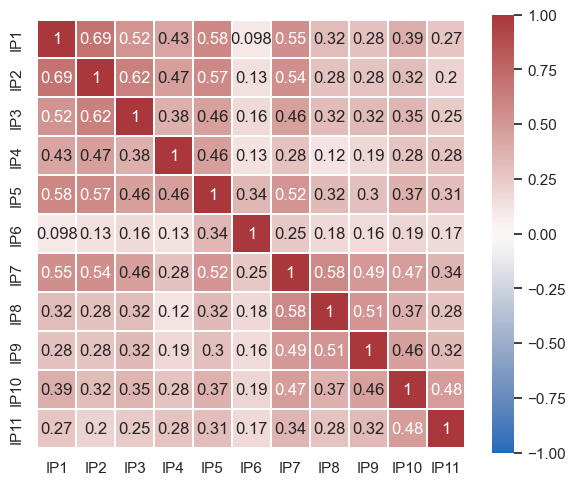

In [90]:
# Schauen wir uns die Korrelation mit anderen Fragen in diesem Block näher an:
fragebogen.plot_corr(df.filter(regex=r"^IP.($|[^34])"), annot=True)

Die Faktoren-Analyse bestätigt unsere ursprüngliche Fragenaufteilung. Sehr gut. Einziger Wermutstropfen:
die Innovationsleistung fällt völlig raus: nachdem wir IP14 eliminiert haben, ist IP13 alleine zu wenig
aussagekräftig. (Wir könnten später eine gesonderte Regression nur für valide Werte von IP14 machen,
allerdings ist bei einer so hohen Fehlerquote das Ergebnis schwer interpretierbar.)
Testen wir noch die einzelnen Faktoren auf interne Konsistenz. Ein Maß dafür ist Cronbachs Alpha:

### Cronbachs Alpha

**Cronbachs Alpha** ist ein Maß für die **interne Konsistenz** einer Skala. Es beschreibt, wie gut mehrere Items dasselbe zugrunde liegende Merkmal messen. Hohe Werte bedeuten, dass die Items stark miteinander zusammenhängen und somit wahrscheinlich dasselbe Konstrukt erfassen.

Typische Richtwerte sind:

| Cronbachs Alpha | Interpretation                              |
| --------------- | ------------------------------------------- |
| < 0,60          | unzureichend                                |
| 0,60 – 0,69     | fragwürdig                                  |
| 0,70 – 0,79     | akzeptabel                                  |
| 0,80 – 0,89     | gut                                         |
| ≥ 0,90          | sehr gut                                    |
| > 0,95          | möglicherweise redundant (Items zu ähnlich) |

**Wichtig:** Ein hohes Cronbachs Alpha bedeutet nicht automatisch, dass eine Skala eindimensional oder inhaltlich valide ist. Es zeigt lediglich, dass die Items konsistent miteinander zusammenhängen. Daher sollte Cronbachs Alpha immer zusammen mit einer Faktorenanalyse und einer inhaltlichen Prüfung der Items betrachtet werden.


In [91]:
from pingouin import cronbach_alpha

In [92]:
cronbach_alpha(df[["IP1","IP2","IP3","IP4","IP5"]])

(np.float64(0.8410964941800685), array([0.808, 0.87 ]))

In [93]:
cronbach_alpha(df[["IP7", "IP8","IP9","IP10","IP11"]])

(np.float64(0.7906774477070494), array([0.747, 0.829]))

In [94]:
cronbach_alpha(df[["IP6", "IP7", "IP8","IP9","IP10","IP11"]]) # etwas schwächer

(np.float64(0.7585481655398228), array([0.71 , 0.802]))

In [95]:
cronbach_alpha(df[["PI1","PI2","PI3"]])

(np.float64(0.8470623863084056), array([0.812, 0.877]))

In [96]:
cronbach_alpha(df[["FP1","FP2","FP3"]])

(np.float64(0.8048058257350945), array([0.759, 0.843]))

# Unabhängige Variable

In [97]:
fragebogen.kaiser_kriterium(df[items_unabh])

np.int64(10)

Der Fragebogen war so entworfen, dass wir die **Absorptionskapazität** eines Unternehmens in vier Bestandteile aufsplitten: *acquire
and assimilate knowledge* (collect ideas, Fragen CIx) und *transform and exploit knowledge* (transform ideas,
Fragen TIx). In der Analyse zeigt sich, dass die Unterscheidung in vier Faktoren wohl nicht zufriedenstellend
gelingen wird:

1. TR1-TR4 ... Trust in Region
2. DI1-DI4 ... Environmental Dynamism
3. EC1-EC3 ... Environmental Competitiveness
4. CI1-CI6 ... Acquire Knowledge
5. CI7-CI9 ... Assimilate Knowledge
6. TI1-TI6 ... Transform Knowledge
7. TI7-TI12 ... Exploit Knowledge
8. BS1-BS6 ... Business Strategy
9. CM0-CM4 ... Kooperation with Cluster Management

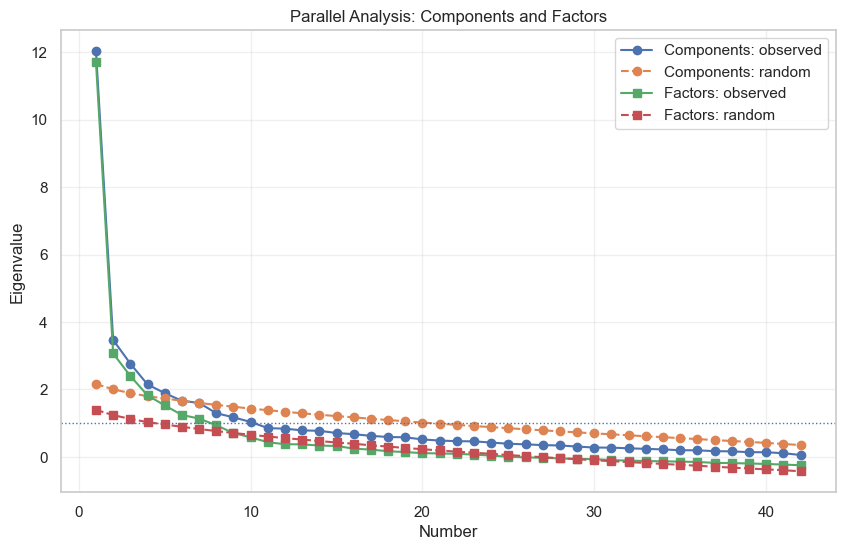

Empfohlene Anzahl an Komponenten: 5
Empfohlene Anzahl an Faktoren: 8


In [98]:
pa_unabh = fragebogen.parallel_analysis(df[items_unabh], n_iter=500, fa="both")
fragebogen.plot_parallel_analysis(pa_unabh)

Hier unterscheiden sich Kaiser-Kriterium (10 Faktoren) und die parallele Analyse (5-8). Wir messen der parallelen
Analyse mehr Gewicht zu. D.h. aber auch, dass offensichtlich unser Aufsplitten der Absorptionskapazität
in 4 Faktoren mit diesem Fragebogen nicht sinnvoll scheint. Wir probieren einfach verschiedene Analysen aus.

In [99]:
fragebogen.print_factor_loadings(df[items_unabh], n_factors=9)

                   F1     F2     F3     F4     F5     F6     F7     F8     F9
TR1                                                0.835                     
TR2                                                0.716                     
TR3                                                0.643                     
TR4                                                0.729                     
DI1                           0.610                                          
DI2                           0.980                                          
DI3                           0.670                                          
DI4                           0.708                                          
EC1                                         0.712                            
EC2                                         0.823                            
EC3                                         0.791                            
CI1                                                             

In [100]:
fragebogen.print_factor_loadings(df[items_unabh], n_factors=7)

                   F1     F2     F3     F4     F5     F6     F7
TR1                                         0.802              
TR2                                         0.726              
TR3                                         0.532              
TR4                                         0.757              
DI1                                  0.663                     
DI2                                  0.920                     
DI3                                  0.764                     
DI4                                  0.644                     
EC1                    0.622                                   
EC2                    0.676                                   
EC3                    0.850                                   
CI1             0.412                                     0.475
CI2                                                            
CI3                                                       0.431
CI4                                     

In [109]:
analyzer = fa.FactorAnalyzer(n_factors=6, rotation="promax")
fa_fit = analyzer.fit(df[items_unabh])
fragebogen.print_fa_fit_loadings(fa_fit, items_unabh, cutoff=0.4)

                   F1     F2     F3     F4     F5     F6
TR1                                  0.854              
TR2                                  0.770              
TR3                                  0.565              
TR4                                  0.805              
DI1                           0.694                     
DI2                           0.971                     
DI3                           0.780                     
DI4                           0.677                     
EC1             0.689                                   
EC2             0.656                                   
EC3             0.757                                   
CI1                    0.854                            
CI2                                                     
CI3                    0.533                            
CI4                                                     
CI5                                                     
CI6                    0.735   

Während der Großteil der Faktoren mit unseren Plänen übereinstimmt, sind die Faktoren, welche die
Absorptionsfähigkeit betreffen uneinheitlich und lassen sich in dieser Konstellation nur schwer theoretisch
begründen. Wir haben uns deshalb entschieden, beide Faktoren zu einem einzigen zusammenzulegen. Prüfen
wir wieder Cronbachs Alpha, das durchwegs gut ist:

In [110]:
cronbach_alpha(df[["TR1","TR2","TR3","TR4"]])

(np.float64(0.8098671623190491), array([0.769, 0.845]))

In [111]:
cronbach_alpha(df[["DI1","DI2","DI3","DI4"]])

(np.float64(0.8022204910920683), array([0.76 , 0.839]))

In [112]:
cronbach_alpha(df[["EC1","EC2","EC3"]])

(np.float64(0.7983940556932141), array([0.752, 0.838]))

In [113]:
cronbach_alpha(df[["BS1","BS3","BS4","BS5"]]) # "BS2", "BS6" entfernt

(np.float64(0.8793224932752413), array([0.853, 0.902]))

In [114]:
cronbach_alpha(df[["CM1","CM2","CM3","CM4"]])

(np.float64(0.8369785842301478), array([0.802, 0.867]))

In [115]:
cronbach_alpha(df[["CI1","CI3","CI6","CI8","CI9","TI1","TI2","TI3","TI6","TI7","TI9","TI10","TI12"]])

(np.float64(0.8948224910767496), array([0.875, 0.913]))

In [138]:
def zscale(s):
    return (s - s.mean()) / s.std()

cpfac = pd.DataFrame({
    # abhängige Variablen
    "ExploitInno": zscale(df[["IP1", "IP2", "IP3", "IP4", "IP5"]].sum(axis=1, skipna=False)),
    "ExploreInno": zscale(df[["IP7", "IP8", "IP9", "IP10", "IP11"]].sum(axis=1, skipna=False)),
    "ProcessInno": zscale(df[["PI1", "PI2", "PI3"]].sum(axis=1, skipna=False)),
    "FirmPerf": zscale(df[["FP1", "FP2", "FP3"]].sum(axis=1, skipna=False)),

    # unabhängige Faktoren
    "TrustInRegion": zscale(df[["TR1", "TR2", "TR3", "TR4"]].sum(axis=1, skipna=False)),
    "EnvironDyn": zscale(df[["DI1", "DI2", "DI3", "DI4"]].sum(axis=1, skipna=False)),
    "EnvironComp": zscale(df[["EC1", "EC2", "EC3"]].sum(axis=1, skipna=False)),
    "Strategy": zscale(df[["BS1", "BS3", "BS4", "BS5"]].sum(axis=1, skipna=False)),
    "ClusterMgmt": zscale(df[["CM1", "CM2", "CM3", "CM4"]].sum(axis=1, skipna=False)),

    "AbsorpCap": zscale(df[[
        "CI1", "CI3", "CI4", "CI6", "CI8", "CI9",
        "TI1", "TI2", "TI3", "TI6", "TI7", "TI9", "TI10", "TI12"
    ]].sum(axis=1, skipna=False)),

    # weitere unabh. Faktoren und Daten
    "ClusterNr": df["ClusterNr"],
    "FirmAgeLog": df["FirmAgeLog"],
    "FirmSizeLog": df["FirmSizeLog"],

    "CommonFactor": zscale(df[[
        "TR1", "TR2", "TR3", "TR4",
        "DI1", "DI2", "DI3", "DI4",
        "EC1", "EC2", "EC3",
        "BS1", "BS3", "BS4", "BS5",
        "CM1", "CM2", "CM3", "CM4",
        "CI1", "CI3", "CI4", "CI6", "CI8", "CI9",
        "TI1", "TI2", "TI3", "TI6", "TI7", "TI9", "TI10", "TI12",
        "CI2", "CI5", "CI7", "TI4", "TI8", "TI11"
    ]].sum(axis=1, skipna=False))
})

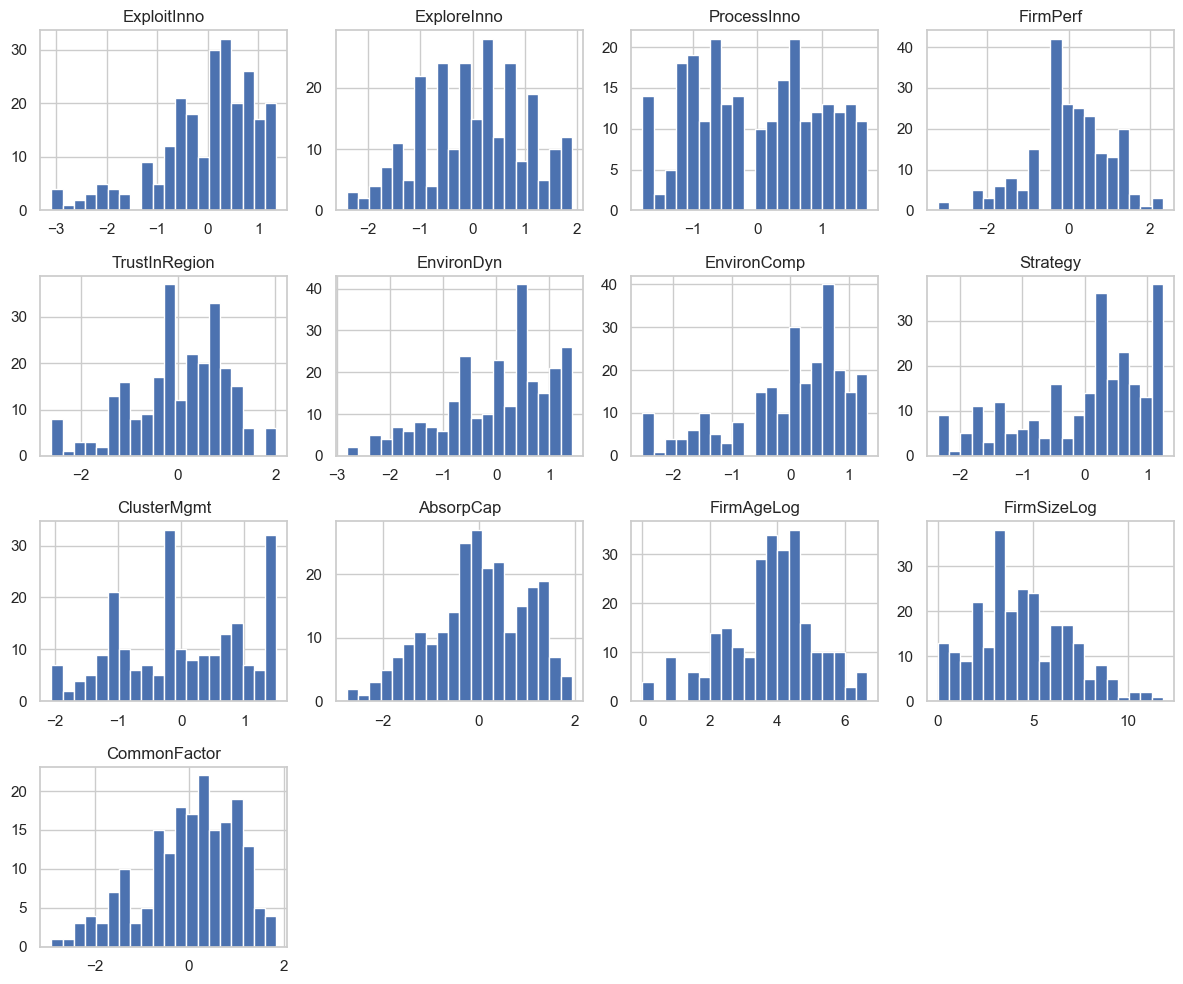

In [139]:
cpfac.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

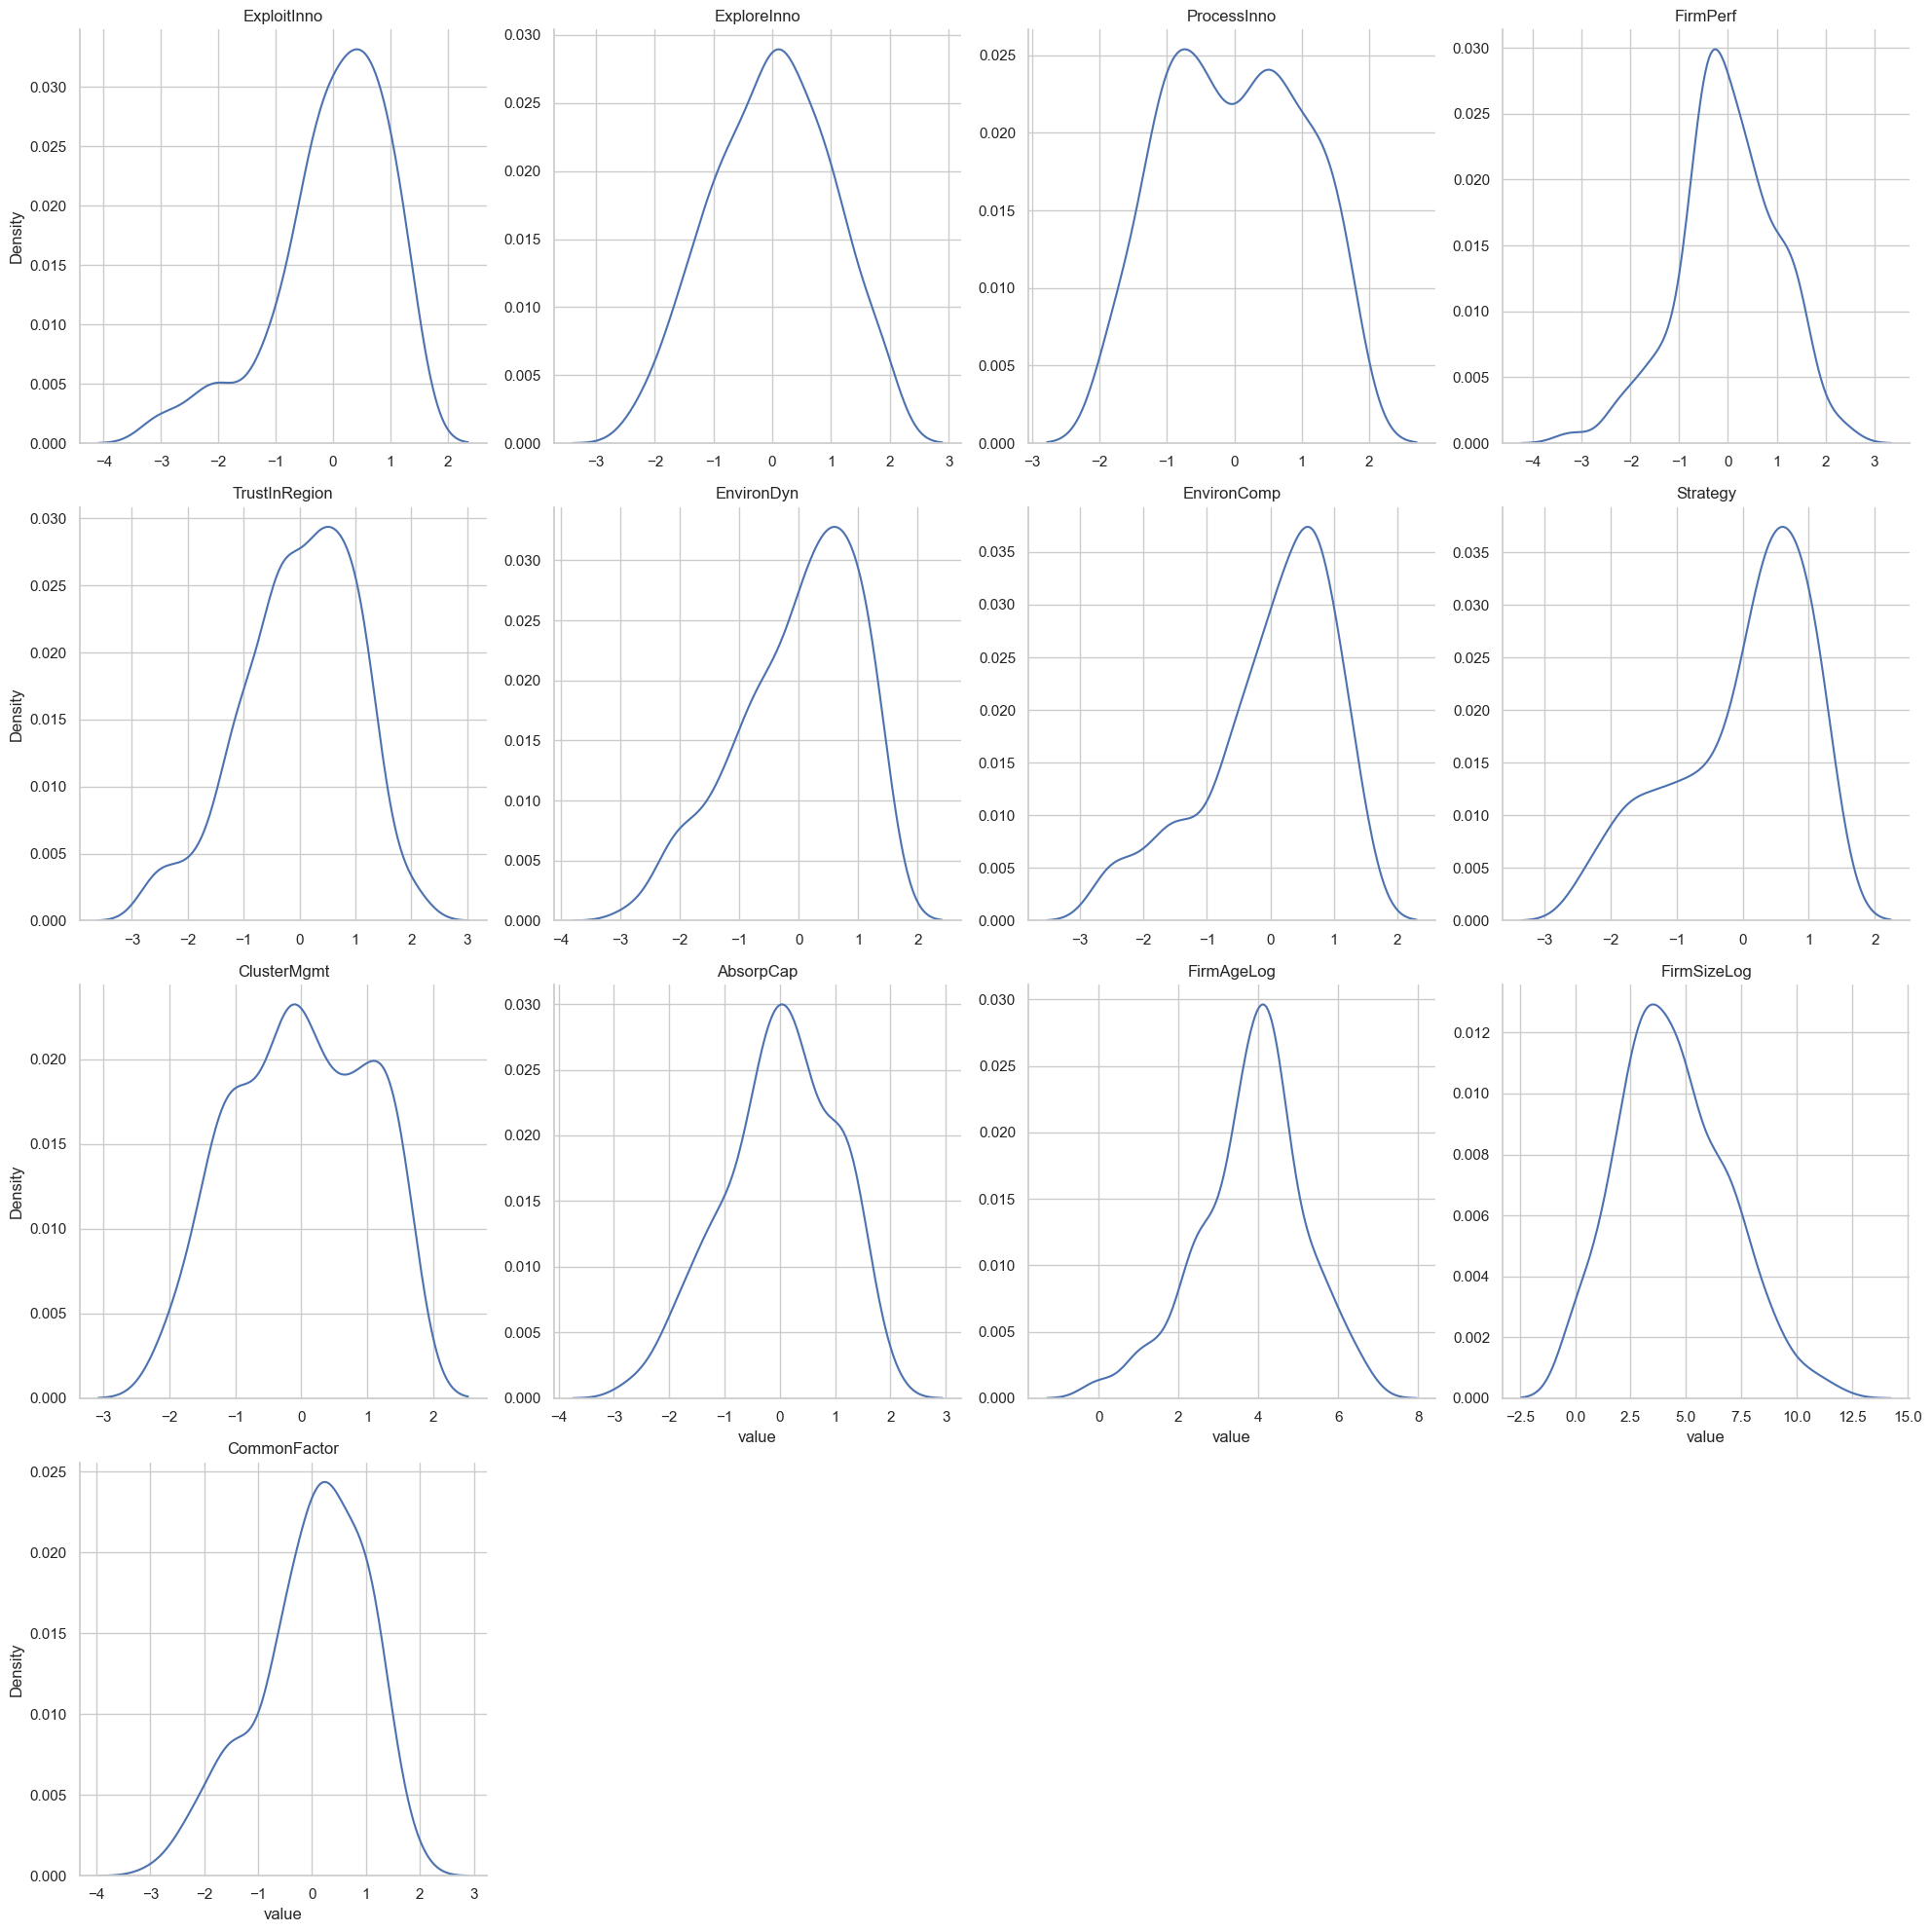

In [140]:
fragebogen.plot_density(cpfac)

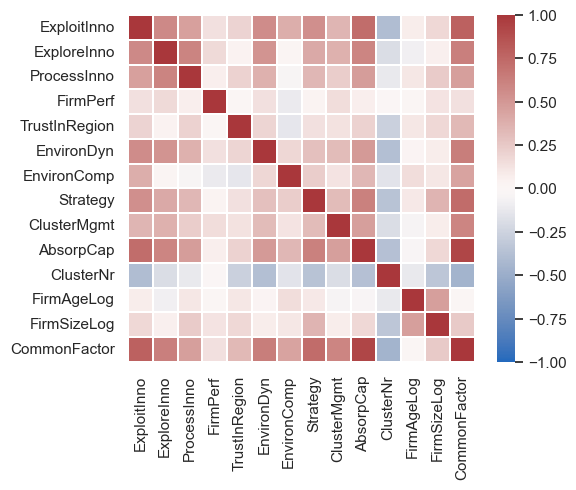

In [141]:
# Schauen wir uns die Korrelation mit anderen Fragen in diesem Block näher an:
fragebogen.plot_corr(cpfac)
# Die Matrix ist vielversprechend. Nicht weiter verwunderlich: finanzieller Erfolg der Firma hat nur geringe
# Korrelation. Dafür spielen beim Firmenerfolg einfach zu viele Faktoren eine Rolle.

## Common Method Bias

Das Histogramm des CommonFactor zeigt an, dass die Antworten des Fragebogens prinzipiell eher zu höheren
Werten tendieren. Es könnte sich dabei um einen systematischen Fehler des Fragebogens handeln. Wir werden
diesen Faktor in unsere Regressionsgleichungen aufnehmen, um zu sehen, welchen Einfluss er hat.

Ein einfacher (nicht immer zuverlässiger Test) ist *Harman’s single factor test*. Da berechnen wir einen einzigen
Faktor aus allen Fragen. Das Ergebnis ist mit Proportion Var 0.3 (erklärte Streuung) noch im akzeptablen Bereich.

In [142]:
fragebogen.harman_single_factor_test(cpfac)

                   F1
ExploitInno     0.804
ExploreInno     0.651
ProcessInno     0.535
FirmPerf             
TrustInRegion        
EnvironDyn      0.624
EnvironComp          
Strategy        0.655
ClusterMgmt     0.473
AbsorpCap       0.855
ClusterNr      -0.462
FirmAgeLog           
FirmSizeLog          
CommonFactor    0.919

SS loadings     4.437
Proportion Var  0.317
Cumulative Var  0.317
